# 0. Setup

In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    cohen_kappa_score,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
)

from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount("/content/drive")
# ---- base directory: change this to where your CSVs live ----
BASE_DIR = "/content/drive/MyDrive/NLP_Projects/HateSpeech"

Mounted at /content/drive


# 1. Read in csv that contains human labeling and mini-4o labeling

In [3]:
df_path = os.path.join(BASE_DIR, "hatexplain_model_ready_with_ai_labels.csv")
df = pd.read_csv(df_path)
df.head()

,id,text,label_id1,label_id2,label_id3,human_majority,is_pure,human_pure,ai_label_mini,ai_label_text_mini,ai_p_normal_mini,ai_p_offensive_mini,ai_p_hate_mini
0,1179055004553900032_twitter,i dont think im getting my baby them white 9 h...,normal,normal,normal,normal,True,normal,NORMAL,normal,0.90,0.1,0.00
1,1179063826874032128_twitter,we cannot continue calling ourselves feminists...,normal,normal,normal,normal,True,normal,NORMAL,normal,0.85,0.1,0.05
2,1178793830532956161_twitter,nawt yall niggers ignoring me,normal,normal,hatespeech,normal,False,NaN,HATE,hatespeech,0.00,0.1,0.90
3,1179088797964763136_twitter,<user> i am bit confused coz chinese ppl can n...,hatespeech,offensive,hatespeech,hatespeech,False,NaN,HATE,hatespeech,0.00,0.2,0.80
4,1179085312976445440_twitter,this bitch in whataburger eating a burger with...,hatespeech,hatespeech,offensive,hatespeech,False,NaN,HATE,hatespeech,0.00,0.1,0.90


# 2. Explore dataset

## 2.1 How many records do we have in total?

In [4]:
print("Total rows:", len(df))

Total rows: 20148


## 2.2 Any duplicate text we have? If so, how many?

In [5]:
# Count occurrences of each text
text_counts = df["text"].value_counts()

# Texts that appear more than once
dup_texts = text_counts[text_counts > 1]

print("Number of unique texts:", df["text"].nunique())
print("Number of texts with duplicates:", len(dup_texts))
print("Total rows belonging to duplicated texts:", df[df["text"].isin(dup_texts.index)].shape[0])

Number of unique texts: 20109
Number of texts with duplicates: 23
Total rows belonging to duplicated texts: 62


## 2.3 Check label consistency within each duplicated text

### 2.3.1. Compute consistency flags

In [6]:
# Focus only on duplicated texts
df_dup = df[df["text"].isin(dup_texts.index)].copy()

label_cols = ["human_majority", "human_pure", "ai_label_text_mini"]

# For each text, compute number of unique values per label column
grouped = (
    df_dup
    .groupby("text")[label_cols]
    .nunique()
    .reset_index()
    .rename(columns={
        "human_majority": "n_unique_human_majority",
        "human_pure": "n_unique_human_pure",
        "ai_label_text_mini": "n_unique_ai_label",
    })
)

# Flag consistency (True if all duplicates share the same label for that column)
grouped["consistent_human_majority"] = grouped["n_unique_human_majority"] == 1
grouped["consistent_human_pure"] = grouped["n_unique_human_pure"] == 1
grouped["consistent_ai_label"] = grouped["n_unique_ai_label"] == 1

# Overall: all three consistent?
grouped["consistent_all_three"] = (
    grouped["consistent_human_majority"]
    & grouped["consistent_human_pure"]
    & grouped["consistent_ai_label"]
)


### 2.3.2. Summary statistics

In [7]:
print("Duplicated texts (N):", len(grouped))
print("Texts with all three labels consistent:", grouped["consistent_all_three"].sum())
print("Texts with any inconsistency:", (~grouped["consistent_all_three"]).sum())

print("\nBreakdown by label type:")
for col in ["consistent_human_majority", "consistent_human_pure", "consistent_ai_label"]:
    print(col, "→", grouped[col].sum(), "consistent out of", len(grouped))

Duplicated texts (N): 23
Texts with all three labels consistent: 12
Texts with any inconsistency: 11

Breakdown by label type:
consistent_human_majority → 17 consistent out of 23
consistent_human_pure → 18 consistent out of 23
consistent_ai_label → 19 consistent out of 23


### 2.3.3. Inspect problematic cases

In [8]:
# Texts with any inconsistency
problem_texts = grouped.loc[~grouped["consistent_all_three"], "text"]

df_problems = df_dup[df_dup["text"].isin(problem_texts)].copy()

# Sort so you can read them easily
df_problems = df_problems.sort_values(["text", "human_majority", "human_pure", "ai_label_text_mini"])


### 2.3.4 Generate cvs for inspection

In [9]:
summary_csv_path = os.path.join(BASE_DIR, "dup_text_label_consistency_summary.csv")
problems_csv_path = os.path.join(BASE_DIR, "dup_text_label_inconsistencies_detailed.csv")

grouped.to_csv(summary_csv_path, index=False)
df_problems.to_csv(problems_csv_path, index=False)

print("\nSaved summary to:", summary_csv_path)
print("Saved detailed problems to:", problems_csv_path)


Saved summary to: /content/drive/MyDrive/NLP_Projects/HateSpeech/dup_text_label_consistency_summary.csv
Saved detailed problems to: /content/drive/MyDrive/NLP_Projects/HateSpeech/dup_text_label_inconsistencies_detailed.csv


# 3. Agreement Evaluation

## 3.1 Pairwise human–human $\kappa$

In [10]:
# Use these columns (they contain 'normal'/'offensive'/'hatespeech')
human_label_cols = ["label_id1", "label_id2", "label_id3"]
human_label_cols = [c for c in human_label_cols if c in df.columns]

print("Human label cols found:", human_label_cols)
for c in human_label_cols:
    print(c, "non-missing count:", df[c].notna().sum())

def compute_pairwise_kappas(df, label_cols):
    rows = []
    label_cols = [c for c in label_cols if c in df.columns]
    if len(label_cols) < 2:
        print("Not enough human label columns to compute pairwise κ.")
        return pd.DataFrame()

    for i in range(len(label_cols)):
        for j in range(i + 1, len(label_cols)):
            c1, c2 = label_cols[i], label_cols[j]
            mask = df[c1].notna() & df[c2].notna()
            n_pair = int(mask.sum())
            if n_pair == 0:
                continue
            kappa = cohen_kappa_score(df.loc[mask, c1], df.loc[mask, c2])
            rows.append({
                "rater1": c1,
                "rater2": c2,
                "kappa": kappa,
                "n": n_pair,
            })
    return pd.DataFrame(rows)

df_kappa_human = compute_pairwise_kappas(df, human_label_cols)
print(df_kappa_human)

if df_kappa_human.empty:
    print("No pairwise κ could be computed.")
else:
    print("Mean human–human κ:", df_kappa_human["kappa"].mean())

Human label cols found: ['label_id1', 'label_id2', 'label_id3']
label_id1 non-missing count: 20148
label_id2 non-missing count: 20148
label_id3 non-missing count: 20148
      rater1     rater2     kappa      n
0  label_id1  label_id2  0.460638  20148
1  label_id1  label_id3  0.457706  20148
2  label_id2  label_id3  0.460755  20148
Mean human–human κ: 0.4596995256795391


## 3.2 Human-AI $\kappa$

In [11]:
# use ai_label_mini (uppercase) or ai_label_text_mini; we normalize anyway
df["ai_label_text_mini"] = df["ai_label_text_mini"].astype(str).str.lower().str.strip()

### 3.2.1 Kappa: AI vs human-majority

In [12]:
mask_major = df["human_majority"].notna() & df["ai_label_text_mini"].notna()
y_h_major = df.loc[mask_major, "human_majority"]
y_ai_major = df.loc[mask_major, "ai_label_text_mini"]

kappa_major = cohen_kappa_score(y_h_major, y_ai_major)
print(f"AI vs human-majority: n={mask_major.sum()}, κ={kappa_major:.3f}")

AI vs human-majority: n=19229, κ=0.360


### 3.2.2 Kappa: AI vs human-pure

In [13]:
mask_pure = df["human_pure"].notna() & df["ai_label_text_mini"].notna()
y_h_pure = df.loc[mask_pure, "human_pure"]
y_ai_pure = df.loc[mask_pure, "ai_label_text_mini"]

kappa_pure = cohen_kappa_score(y_h_pure, y_ai_pure)
print(f"AI vs human-pure: n={mask_pure.sum()}, κ={kappa_pure:.3f}")

AI vs human-pure: n=9845, κ=0.434


### 3.2.3. Kappa: AI vs **any** human rater (pooled label_id1–3)

In [14]:
human_rater_cols = ["label_id1", "label_id2", "label_id3"]

# make sure everything is lowercased already
for c in human_rater_cols + ["ai_label_text_mini"]:
    df[c] = df[c].astype(str).str.lower().str.strip()

# keep rows where AI label is present
mask_any = df["ai_label_text_mini"].notna()
sub_any = df.loc[mask_any, ["ai_label_text_mini"] + human_rater_cols].copy()

def ai_matches_any_human(row):
    ai = row["ai_label_text_mini"]
    humans = [row[c] for c in human_rater_cols if pd.notna(row[c])]
    return ai in humans

sub_any["any_match"] = sub_any.apply(ai_matches_any_human, axis=1)

n_items = len(sub_any)
n_agree_any = sub_any["any_match"].sum()
prop_agree_any = n_agree_any / n_items

print(f"AI vs any human (item-level): n={n_items}, "
      f"items with at least one agreeing human rater={n_agree_any} "
      f"({prop_agree_any:.3f})")

AI vs any human (item-level): n=20148, items with at least one agreeing human rater=14752 (0.732)


# 4. Confusion Matrix

In [15]:
def plot_confusion_matrix_counts_and_pct(
    y_row, y_col, labels, row_name="Rater A", col_name="Rater B",
    title="Confusion matrix", figsize=(5, 4), save_path=None, dpi=300,
):
    """
    Confusion matrix with:
      - heatmap colors based on raw counts
      - annotations 'count (xx.x%)', where % is of total N (not row-wise)
      - optional saving to file
      - grey colormap for print-friendly figures
    """
    cm = confusion_matrix(y_row, y_col, labels=labels)  # integer counts
    total = cm.sum()

    # Build annotation strings: "count (xx.x%)" with % of total
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            pct = 100.0 * count / total if total > 0 else 0.0
            annot[i, j] = f"{count}\n({pct:.1f}%)"

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Greys",          # grey colormap
        xticklabels=labels,
        yticklabels=labels,
        vmin=0,
        vmax=None,
        cbar=False,            # optional: remove colorbar for cleaner grayscale
    )
    plt.xlabel(col_name)
    plt.ylabel(row_name)
    plt.title(title)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi)
        print("Saved confusion matrix to:", save_path)

    plt.show()
    plt.close()

    return cm

Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/cm_rater1_rater2.png


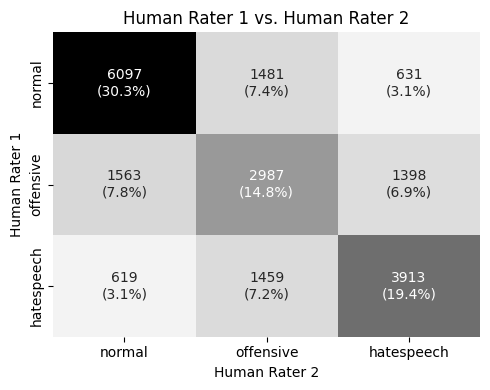

Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/cm_rater1_rater3.png


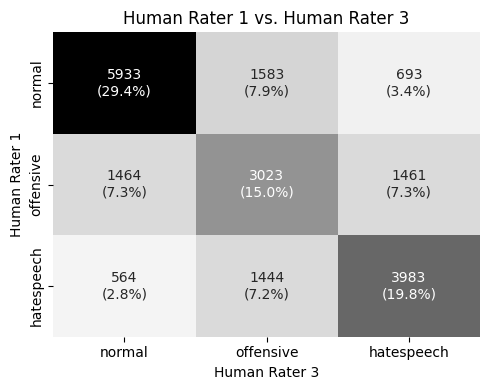

Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/cm_rater2_rater3.png


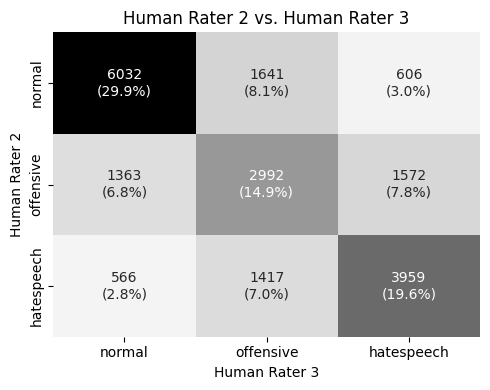

Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/cm_majority_mini4o.png


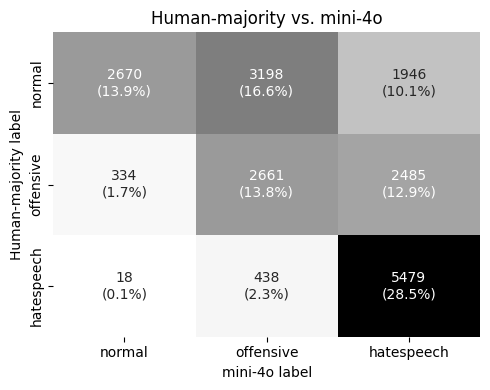

Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/cm_pure_mini4o.png


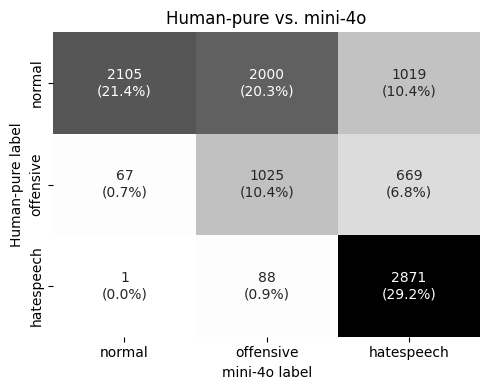

array([[2105, 2000, 1019],
       [  67, 1025,  669],
       [   1,   88, 2871]])

In [ ]:
label_order = ["normal", "offensive", "hatespeech"]

# Human Rater 1 vs Human Rater 2 (label_id1 vs label_id2)
mask = df["label_id1"].notna() & df["label_id2"].notna()
y_row = df.loc[mask, "label_id1"]   # Human Rater 1
y_col = df.loc[mask, "label_id2"]   # Human Rater 2

plot_confusion_matrix_counts_and_pct(
    y_row, y_col, labels = label_order,
    row_name = "Human Rater 1",              # y-axis label
    col_name = "Human Rater 2",              # x-axis label
    title = "Human Rater 1 vs. Human Rater 2",
    figsize = (5, 4),
    save_path = os.path.join(BASE_DIR, "cm_rater1_rater2.png"),
)

# Human Rater 1 vs Human Rater 3 (label_id1 vs label_id3)
mask13 = df["label_id1"].notna() & df["label_id3"].notna()
y_row_13 = df.loc[mask13, "label_id1"]   # Human Rater 1
y_col_13 = df.loc[mask13, "label_id3"]   # Human Rater 3

plot_confusion_matrix_counts_and_pct(
    y_row_13, y_col_13, labels = label_order,
    row_name = "Human Rater 1", col_name="Human Rater 3",
    title = "Human Rater 1 vs. Human Rater 3",
    figsize = (5, 4),
    save_path = os.path.join(BASE_DIR, "cm_rater1_rater3.png"),
)

# Human Rater 2 vs Human Rater 3 (label_id2 vs label_id3)
mask23 = df["label_id2"].notna() & df["label_id3"].notna()
y_row_23 = df.loc[mask23, "label_id2"]   # Human Rater 2
y_col_23 = df.loc[mask23, "label_id3"]   # Human Rater 3

plot_confusion_matrix_counts_and_pct(
    y_row_23, y_col_23, labels = label_order,
    row_name = "Human Rater 2", col_name = "Human Rater 3",
    title = "Human Rater 2 vs. Human Rater 3",
    figsize = (5, 4),
    save_path = os.path.join(BASE_DIR, "cm_rater2_rater3.png"),
)

# ------------------------------------------------------------------
# 4. Human aggregation vs mini-4o
# ------------------------------------------------------------------

# Human-majority vs mini-4o
mask_major = df["human_majority"].notna() & df["ai_label_text_mini"].notna()
y_row_major = df.loc[mask_major, "human_majority"]       # Human-majority
y_col_major = df.loc[mask_major, "ai_label_text_mini"]   # mini-4o

plot_confusion_matrix_counts_and_pct(
    y_row_major, y_col_major, labels = label_order,
    row_name = "Human-majority label", col_name = "mini-4o label",
    title = "Human-majority vs. mini-4o",
    figsize = (5, 4),
    save_path = os.path.join(BASE_DIR, "cm_majority_mini4o.png"),
)

# Human-pure vs mini-4o
mask_pure = df["human_pure"].notna() & df["ai_label_text_mini"].notna()
y_row_pure = df.loc[mask_pure, "human_pure"]             # Human-pure
y_col_pure = df.loc[mask_pure, "ai_label_text_mini"]     # mini-4o

plot_confusion_matrix_counts_and_pct(
    y_row_pure, y_col_pure, labels = label_order,
    row_name = "Human-pure label", col_name = "mini-4o label",
    title = "Human-pure vs. mini-4o", figsize = (5, 4),
    save_path = os.path.join(BASE_DIR, "cm_pure_mini4o.png"),
)

# 5. Entropy of mini-4o labeling

## 5.1. Compute Shannon entropy from mini-4o probabilities

In [16]:
prob_cols = ["ai_p_normal_mini", "ai_p_offensive_mini", "ai_p_hate_mini"]

# make sure we have numeric probabilities
probs = df[prob_cols].astype(float).clip(lower = 0).to_numpy()
row_sums = probs.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0            # avoid division by zero
probs_norm = probs / row_sums

eps = 1e-12
# entropy in nats (use np.log2 if you want bits instead)
mini_entropy = -np.sum(probs_norm * np.log(probs_norm + eps), axis=1)

df["mini_entropy"] = mini_entropy

print(df["mini_entropy"].describe())

count    2.014800e+04
mean     2.070860e-01
std      2.182361e-01
min     -1.000089e-12
25%     -1.000089e-12
50%      3.250830e-01
75%      3.250830e-01
max      1.029653e+00
Name: mini_entropy, dtype: float64


N total: 20148
N zero-ish: 9681
N > 0: 10467


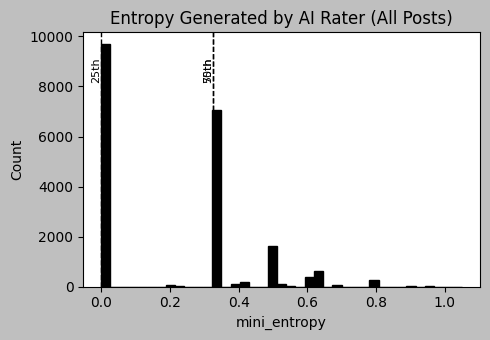

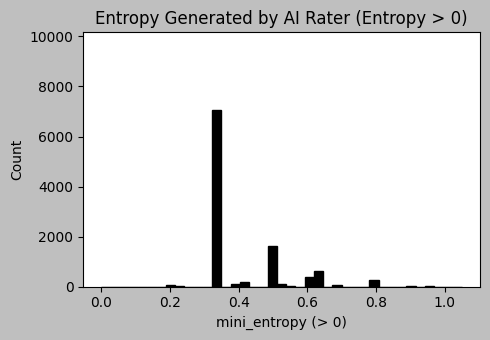

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Use grayscale style for all plots
plt.style.use("grayscale")

BASE_DIR = "/content/drive/MyDrive/NLP_Projects/HateSpeech"

ent = df["mini_entropy"].to_numpy()

# Clip tiny negatives to 0
ent_clip = np.clip(ent, 0.0, None)

eps = 1e-6
is_zero = ent_clip < eps
ent_zero = ent_clip[is_zero]
ent_pos = ent_clip[~is_zero]

print("N total:", ent_clip.size)
print("N zero-ish:", ent_zero.size)
print("N > 0:", ent_pos.size)

# ---------- common settings ----------
# Bins
bins_all = np.linspace(0, ent_clip.max() + 0.02, 40)
bins_pos = np.linspace(0, ent_pos.max() + 0.02, 40)

# Precompute counts to share the same y-limit
counts_all, _ = np.histogram(ent_clip, bins=bins_all)
counts_pos, _ = np.histogram(ent_pos, bins=bins_pos)
ymax = 1.05 * max(counts_all.max(), counts_pos.max())

# Quartiles for the full distribution
qs = np.quantile(ent_clip, [0.25, 0.5, 0.75])

# ---------- Figure 1: all posts ----------
plt.figure(figsize=(5, 3.5))
plt.hist(ent_clip, bins=bins_all, edgecolor="black")
plt.xlabel("mini_entropy")
plt.ylabel("Count")
plt.title("Entropy Generated by AI Rater (All Posts)")
plt.ylim(0, ymax)

for v, lab in zip(qs, ["25th", "50th", "75th"]):
    plt.axvline(v, linestyle="--", linewidth=1)
    plt.text(
        v, ymax * 0.9,
        lab,
        rotation = 90,
        va = "top",
        ha = "right",
        fontsize = 8,
    )

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "entropy_all.png"), dpi=300)
plt.show()

# ---------- Figure 2: entropy > 0 ----------
plt.figure(figsize = (5, 3.5))
plt.hist(ent_pos, bins = bins_pos, edgecolor = "black")
plt.xlabel("mini_entropy (> 0)")
plt.ylabel("Count")
plt.title("Entropy Generated by AI Rater (Entropy > 0)")
plt.ylim(0, ymax)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "entropy_pos.png"), dpi = 300)
plt.show()

## 5.2. By agreement vs human-pure:

In [17]:
# only where we have pure labels
mask = df["human_pure"].notna() & df["ai_label_text_mini"].notna()
sub = df.loc[mask].copy()
sub["disagree_pure"] = (sub["human_pure"] != sub["ai_label_text_mini"]).astype(int)

ent_agree = sub.loc[sub["disagree_pure"] == 0, "mini_entropy"]
ent_disagree = sub.loc[sub["disagree_pure"] == 1, "mini_entropy"]

print("Entropy (agree with pure):    mean={:.3f}, sd={:.3f}, n={}".format(
    ent_agree.mean(), ent_agree.std(), ent_agree.shape[0]
))
print("Entropy (disagree with pure): mean={:.3f}, sd={:.3f}, n={}".format(
    ent_disagree.mean(), ent_disagree.std(), ent_disagree.shape[0]
))

Entropy (agree with pure):    mean=0.157, sd=0.207, n=6001
Entropy (disagree with pure): mean=0.231, sd=0.223, n=3844


## 5.3. By human-pure class:

In [18]:
print(
    df.groupby("human_pure")["mini_entropy"]
      .agg(["count", "mean", "std"])
      .sort_index()
)

            count      mean       std
human_pure                           
hatespeech   2960  0.091780  0.150387
normal       5124  0.222513  0.234988
offensive    1761  0.237493  0.203867


## 5.4. By human-majority class:

In [19]:
print(
    df.groupby("human_majority")["mini_entropy"]
      .agg(["count", "mean", "std"])
      .sort_index()
)

                count      mean       std
human_majority                           
hatespeech       5935  0.121725  0.169431
normal           7814  0.238740  0.237577
offensive        5480  0.245332  0.211043


In [20]:
# Example with human_pure
mask = df["human_pure"].notna() & df["ai_label_text_mini"].notna()
sub = df.loc[mask].copy()
sub["disagree_pure"] = (sub["human_pure"] != sub["ai_label_text_mini"]).astype(int)

X = sub[["mini_entropy"]].values
y = sub["disagree_pure"].values

logit = LogisticRegression(solver = "lbfgs", max_iter = 1000)
logit.fit(X, y)

coef = float(logit.coef_[0][0])
intercept = float(logit.intercept_[0])
odds_ratio = np.exp(coef)

probs = logit.predict_proba(X)[:, 1]
auc = roc_auc_score(y, probs)

print("Pure model: logit(P(disagree)) = {:.3f} + {:.3f} * entropy".format(intercept, coef))
print("OR per 1-unit entropy:", odds_ratio)
print("AUC:", auc)

Pure model: logit(P(disagree)) = -0.744 + 1.552 * entropy
OR per 1-unit entropy: 4.720958691838792
AUC: 0.5904660834363193


In [21]:
# sub: df with columns ["mini_entropy", "human_pure", "ai_label_text_mini"]
mask = df["human_pure"].notna() & df["ai_label_text_mini"].notna()
sub = df.loc[mask].copy()
sub["disagree_pure"] = (sub["human_pure"] != sub["ai_label_text_mini"]).astype(int)

# Design matrix with intercept
X = sm.add_constant(sub["mini_entropy"])
y = sub["disagree_pure"]

logit_sm = sm.Logit(y, X).fit(disp=False)

print(logit_sm.summary())

# Extract coefficient and 95% CI for entropy, then exponentiate to get OR
coef_entropy = logit_sm.params["mini_entropy"]
se_entropy = logit_sm.bse["mini_entropy"]

# Wald 95% CI on log-odds scale
z = 1.96
lower_log = coef_entropy - z * se_entropy
upper_log = coef_entropy + z * se_entropy

or_est = np.exp(coef_entropy)
or_lower = np.exp(lower_log)
or_upper = np.exp(upper_log)

print(f"Entropy coefficient (log-odds): {coef_entropy:.3f}")
print(f"Odds ratio: {or_est:.3f}")
print(f"95% CI for OR: [{or_lower:.3f}, {or_upper:.3f}]")

                           Logit Regression Results                           
Dep. Variable:          disagree_pure   No. Observations:                 9845
Model:                          Logit   Df Residuals:                     9843
Method:                           MLE   Df Model:                            1
Date:                Fri, 28 Nov 2025   Pseudo R-squ.:                 0.02042
Time:                        20:55:49   Log-Likelihood:                -6451.3
converged:                       True   LL-Null:                       -6585.8
Covariance Type:            nonrobust   LLR p-value:                 1.855e-60
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.7471      0.028    -26.370      0.000      -0.803      -0.692
mini_entropy     1.5664      0.096     16.263      0.000       1.378       1.755
Entropy coefficient (log-odds): 1.566
Odds r

In [22]:
# subset to cases with pure label and AI label
mask = df["human_pure"].notna() & df["ai_label_text_mini"].notna()
sub = df.loc[mask].copy()

# restrict to the three real classes, just in case
valid_classes = ["normal", "offensive", "hatespeech"]
sub = sub[sub["human_pure"].isin(valid_classes)].copy()

# outcome: disagreement with pure label
sub["disagree_pure"] = (sub["human_pure"] != sub["ai_label_text_mini"]).astype(int)

# make sure entropy is numeric
sub["mini_entropy"] = sub["mini_entropy"].astype(float)

# -------------------------------
# Model 2: entropy + human label
# -------------------------------
model2 = smf.logit(
    formula="disagree_pure ~ mini_entropy + C(human_pure)",
    data=sub
).fit(disp=False)

print(model2.summary())

# Odds ratio and CI for entropy
coef_ent = model2.params["mini_entropy"]
conf_ent = model2.conf_int().loc["mini_entropy"]
or_ent = np.exp(coef_ent)
or_ent_low = np.exp(conf_ent[0])
or_ent_high = np.exp(conf_ent[1])

print(f"Entropy OR (adjusted): {or_ent:.3f} "
      f"[{or_ent_low:.3f}, {or_ent_high:.3f}]")

# AUC for model 2
probs2 = model2.predict(sub)
auc2 = roc_auc_score(sub["disagree_pure"], probs2)
print("AUC (entropy + human_pure):", auc2)

                           Logit Regression Results                           
Dep. Variable:          disagree_pure   No. Observations:                 9845
Model:                          Logit   Df Residuals:                     9841
Method:                           MLE   Df Model:                            3
Date:                Fri, 28 Nov 2025   Pseudo R-squ.:                  0.2316
Time:                        20:55:53   Log-Likelihood:                -5060.2
converged:                       True   LL-Null:                       -6585.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -3.5087      0.108    -32.439      0.000      -3.721      -3.297
C(human_pure)[T.normal]        3.7888      0.112     33.814      0.000       3.569 

In [23]:
# Model 3: with interaction
model3 = smf.logit(
    formula="disagree_pure ~ mini_entropy * C(human_pure)",
    data=sub
).fit(disp=False)

print(model3.summary())

                           Logit Regression Results                           
Dep. Variable:          disagree_pure   No. Observations:                 9845
Model:                          Logit   Df Residuals:                     9839
Method:                           MLE   Df Model:                            5
Date:                Fri, 28 Nov 2025   Pseudo R-squ.:                  0.2369
Time:                        20:55:57   Log-Likelihood:                -5025.8
converged:                       True   LL-Null:                       -6585.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  -3.8604      0.150    -25.814      0.000      -4.154      -3.567
C(human_pure)[T.normal]                     